# FIG CESM run evaluations

In [1]:
import os
import sys
import yaml
import argparse
import pandas as pd
from glob import glob
from datetime import datetime, timedelta

import numpy as np
import xarray as xr

sys.path.insert(0, os.path.realpath('../libs/'))
import graph_utils as gu
#import verif_utils as vu

In [2]:
import cmaps
# graph tools
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import matplotlib.colors as colors
import matplotlib.colorbar as cbar
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import matplotlib.lines as mlines
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import cartopy.crs as ccrs
import cartopy.mpl.geoaxes
import cartopy.feature as cfeature

%matplotlib inline

In [3]:
import matplotlib.transforms as mtransforms

In [4]:
fig_keys = {
    'dpi': 150, 
    'orientation':'portrait', 
    'bbox_inches':'tight', 
    'pad_inches':0.1, 
    'transparent':False
}

In [5]:
need_publish = False

if need_publish:
    dpi_ = fig_keys['dpi']
else:
    dpi_ = 75

In [6]:
from numpy.lib.stride_tricks import sliding_window_view

def moving_average_axis(a, window, axis=-1, pad_mode="reflect"):
    a = np.asarray(a, dtype=float)
    if window < 1:
        raise ValueError("window must be >= 1")

    # Asymmetric split works for even/odd windows
    pad_left = (window - 1) // 2
    pad_right = window // 2

    # Build pad widths for all axes; pad only along the chosen axis
    pad_widths = [(0, 0)] * a.ndim
    pad_widths[axis] = (pad_left, pad_right)

    apad = np.pad(a, pad_widths, mode=pad_mode)

    # Sliding windows along `axis`, then NaN-aware average over window dim
    sw = sliding_window_view(apad, window_shape=window, axis=axis)
    return np.nanmean(sw, axis=-1)

from collections import defaultdict

def merge_intervals(intervals):
    """Merge overlapping/adjacent intervals into disjoint union."""
    if not intervals:
        return []
    sorted_ivs = sorted(intervals, key=lambda x: x[0])
    merged = [list(sorted_ivs[0])]
    for start, end in sorted_ivs[1:]:
        if start <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], end)
        else:
            merged.append([start, end])
    return merged


In [8]:
model_names = ['target', 'era5', 'gdas', 'unet',]
varnames = ['WRF_MSLP', 'WRF_PWAT', 'WRF_SP', 'WRF_T2', 'WRF_precip', 'WRF_SPD10']

In [9]:
PLOT_lines_full = {}

list_ds_scores = []
for year in range(2020, 2025):
    zarr_path = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/verification/TC_verification_scores_{year}.zarr'
    ds_ = xr.open_zarr(zarr_path)
    list_ds_scores.append(ds_)

ds_combined = xr.combine_by_coords(list_ds_scores)

for var_ in varnames:
    for model_ in ['era5', 'gdas', 'unet']:
        if model_ == 'unet':
            crps_ = ds_combined['abs_error'].sel(variable=var_, model=model_).isel(region=0).values
            PLOT_lines_full[f'CRPS_{var_}_{model_}'] = crps_
        else:
            crps_ = ds_combined['crps'].sel(variable=var_, model=model_).isel(region=0).values
            PLOT_lines_full[f'CRPS_{var_}_{model_}'] = crps_

In [10]:
PLOT_lines = {}
for year in range(2020, 2025):
    fn_ = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/verification/TC_verification_scores_{year}.zarr'
    ds_scores = xr.open_zarr(fn_)
    PLOT_lines[f'year_{year}'] = ds_scores['time'].values
    
    for var_ in varnames:
        for model_ in ['era5', 'gdas', 'unet']:
            if model_ == 'unet':
                crps_ = ds_scores['abs_error'].sel(variable=var_, model=model_).isel(region=0).values
                PLOT_lines[f'CRPS_{var_}_{model_}_{year}'] = moving_average_axis(crps_, 30*24, axis=0)
            else:
                crps_ = ds_scores['crps'].sel(variable=var_, model=model_).isel(region=0).values
                PLOT_lines[f'CRPS_{var_}_{model_}_{year}'] = moving_average_axis(crps_, 30*24, axis=0)

In [11]:
PLOT_ZES = {}

for var_ in varnames:
    for model_ in model_names:
        if model_ == 'unet' and var_ == 'WRF_precip':
            PLOT_ZES[f'{var_}_{model_}'] = 1e2*np.nanmean(ds_combined['psd'].sel(spec_variable=var_, model=model_).values, axis=0)
        else:
            PLOT_ZES[f'{var_}_{model_}'] = np.nanmean(ds_combined['psd'].sel(spec_variable=var_, model=model_).values, axis=0)

x_lambda = ds_combined['wavelength_km'].values*1e3

In [12]:
raw_cases = [
    # season, hurdat_id, storm, category, track_start, track_end
    (2020, "AL082020", "Hanna",    1, "2020-07-23 00:00", "2020-07-26 00:00"),
    (2020, "AL092020", "Isaias",   1, "2020-07-31 06:00", "2020-08-04 18:00"),
    (2020, "AL142020", "Marco",    1, "2020-08-22 12:00", "2020-08-25 00:00"),
    (2020, "AL132020", "Laura",    4, "2020-08-24 02:00", "2020-08-29 00:00"),
    (2020, "AL192020", "Sally",    2, "2020-09-11 18:00", "2020-09-17 06:00"),
    (2020, "AL252020", "Gamma",    1, "2020-10-03 16:45", "2020-10-06 12:00"),
    (2020, "AL262020", "Delta",    3, "2020-10-07 06:00", "2020-10-10 12:00"),
    (2020, "AL282020", "Zeta",     3, "2020-10-27 03:55", "2020-10-29 12:00"),
    (2020, "AL292020", "Eta",      1, "2020-11-08 00:00", "2020-11-13 06:00"),

    (2021, "AL052021", "Elsa",     1, "2021-07-05 00:00", "2021-07-09 16:30"),
    (2021, "AL082021", "Henri",    1, "2021-08-18 18:00", "2021-08-23 12:00"),
    #(2021, "AL072021", "Grace",    3, "2021-08-19 09:45", "2021-08-21 12:00"),
    (2021, "AL092021", "Ida",      4, "2021-08-27 12:00", "2021-09-01 06:00"),
    (2021, "AL142021", "Nicholas", 1, "2021-09-12 12:00", "2021-09-15 12:00"),

    #(2022, "AL072022", "Fiona",    4, "2022-09-20 00:00", "2022-09-23 06:00"),
    (2022, "AL092022", "Ian",      5, "2022-09-27 00:00", "2022-09-30 18:05"),
    (2022, "AL172022", "Nicole",   1, "2022-11-07 06:00", "2022-11-11 12:00"),

    #(2023, "AL082023", "Franklin", 4, "2023-08-24 00:00", "2023-08-30 12:00"),
    (2023, "AL102023", "Idalia",   4, "2023-08-26 12:00", "2023-08-31 06:00"),
    #(2023, "AL132023", "Lee",      2, "2023-09-13 12:00", "2023-09-15 12:00"),

    (2024, "AL022024", "Beryl",    1, "2024-07-05 11:00", "2024-07-09 06:00"),
    (2024, "AL042024", "Debby",    1, "2024-08-03 00:00", "2024-08-08 18:00"),
    #(2024, "AL052024", "Ernesto",  2, "2024-08-14 18:00", "2024-08-16 06:00"),
    (2024, "AL062024", "Franc.",  2, "2024-09-09 12:00", "2024-09-12 12:00"),
    (2024, "AL092024", "Helene",   4, "2024-09-25 06:00", "2024-09-27 12:00"),
]

TC_names = []
for case in raw_cases:
    season, hurdat_id, storm, category, track_start, track_end = case
    TC_names.append(storm)

#storm_subsets = {}
PLOT_storm = {}
PLOT_storm_zes = {}

for case in raw_cases:
    season, hurdat_id, storm, category, track_start, track_end = case
    
    # Dynamically build the Zarr path using the season/year
    zarr_path = f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/verification/TC_verification_scores_{season}.zarr'
    
    # Open the year-specific dataset
    ds_ = xr.open_zarr(zarr_path)
    
    # Subset using slice (convert to Timestamp for robust matching)
    ds_subset = ds_.sel(time=slice(pd.Timestamp(track_start), pd.Timestamp(track_end)))
    
    # Store the result
    # storm_subsets[hurdat_id] = ds_subset

    for var_ in varnames:
        for model_ in model_names:
            if model_ == 'target':
                zes_ = ds_subset['psd'].sel(spec_variable=var_, model=model_).values
                PLOT_storm_zes[f'{hurdat_id}_{var_}_{model_}'] = np.nanmean(zes_, axis=0) 
            
            if model_ == 'unet':
                crps_ = ds_subset['abs_error'].sel(variable=var_, model=model_).isel(region=0).values
                PLOT_storm[f'{hurdat_id}_{var_}_{model_}'] = np.nanmean(crps_)
                
                zes_ = ds_subset['psd'].sel(spec_variable=var_, model=model_).values
                PLOT_storm_zes[f'{hurdat_id}_{var_}_{model_}'] = np.nanmean(zes_, axis=0)
            
            elif model_ == 'era5' or model_ == 'gdas':
                crps_ = ds_subset['crps'].sel(variable=var_, model=model_).isel(region=0).values
                PLOT_storm[f'{hurdat_id}_{var_}_{model_}'] = np.nanmean(crps_)

                zes_ = ds_subset['psd'].sel(spec_variable=var_, model=model_).values
                PLOT_storm_zes[f'{hurdat_id}_{var_}_{model_}'] = np.nanmean(zes_, axis=0)

In [13]:
raw_cases[18] = (2024, "AL062024", "Francine",  2, "2024-09-09 12:00", "2024-09-12 12:00")

PLOT_HURDAT = {}

for case in raw_cases:
    season, hurdat_id, storm, category, track_start, track_end = case
    ds_TC = xr.open_dataset(f'/glade/derecho/scratch/ksha/DWC_data/CONUS_domain_TC/tc_track_intensity/{season}_{storm}.nc')
    
    PLOT_HURDAT[f'{hurdat_id}_we_era5'] = np.nanmean(np.abs(ds_TC['era5_winderr_hd'].values))
    PLOT_HURDAT[f'{hurdat_id}_we_gdas'] = np.nanmean(np.abs(ds_TC['gdas_winderr_hd'].values))
    PLOT_HURDAT[f'{hurdat_id}_we_unet'] = np.nanmean(np.abs(ds_TC['unet_winderr_hd'].values))
    PLOT_HURDAT[f'{hurdat_id}_we_target'] = np.nanmean(np.abs(ds_TC['c404_winderr_hd'].values))

    PLOT_HURDAT[f'{hurdat_id}_te_era5'] = np.nanmean(np.abs(ds_TC['era5_trkerr_hd'].values))
    PLOT_HURDAT[f'{hurdat_id}_te_gdas'] = np.nanmean(np.abs(ds_TC['gdas_trkerr_hd'].values))
    PLOT_HURDAT[f'{hurdat_id}_te_unet'] = np.nanmean(np.abs(ds_TC['unet_trkerr_hd'].values))
    PLOT_HURDAT[f'{hurdat_id}_te_target'] = np.nanmean(np.abs(ds_TC['c404_trkerr_hd'].values))

    PLOT_HURDAT[f'{hurdat_id}_time'] = ds_TC['time'].values

In [14]:
IND_TC = {}
for i_year, year in enumerate(range(2020, 2025)):
    for i_case, case in enumerate(raw_cases):
        season, hurdat_id, storm, category, track_start, track_end = case
        if season == year:
            IND_TC[f'{hurdat_id}_{year}'] = [
                np.searchsorted(PLOT_lines[f'year_{year}'], PLOT_HURDAT[f'{hurdat_id}_time'][0],),
                np.searchsorted(PLOT_lines[f'year_{year}'], PLOT_HURDAT[f'{hurdat_id}_time'][-1],),
            ]

In [15]:
yearly_merged = {}
groups = defaultdict(list)

for key, interval in IND_TC.items():
    year = key.split('_')[-1]       # e.g., '2020'
    groups[year].append(interval)

for year in sorted(groups):
    yearly_merged[year] = merge_intervals(groups[year])

In [16]:
my_colors = gu.ksha_color_set_summon(color_set=0)
cyan = my_colors['cyan']
blue = my_colors['blue']
red = my_colors['red']
orange = my_colors['orange']

In [17]:
line_keys = {}
line_keys['unet'] = {'linewidth': 3, 'linestyle': '--', 'color': blue, 'alpha': 1, 'zorder': 3, 'label': ''}
line_keys['era5'] = {'linewidth': 3, 'linestyle': '--', 'color': red, 'alpha': 1, 'zorder': 4, 'label': ''}
line_keys['gdas'] = {'linewidth': 3, 'linestyle': '-', 'color': orange, 'alpha': 1, 'zorder': 2, 'label': ''}
line_keys['target'] = {'linewidth': 2.5, 'linestyle': '--', 'color': 'k', 'alpha': 1, 'zorder': 1, 'label': ''}

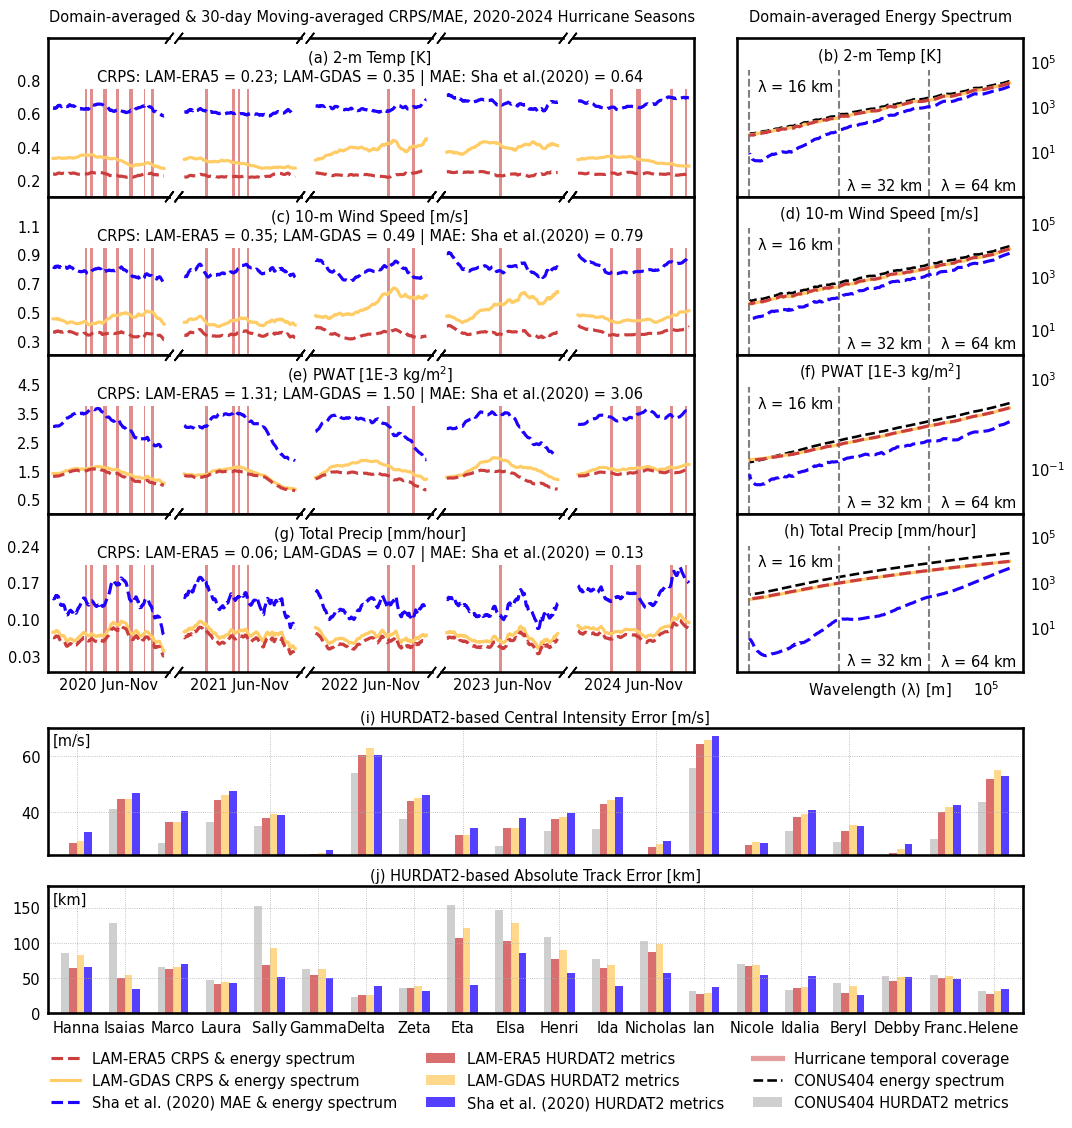

In [18]:
fig = plt.figure(figsize=(13, 13), dpi=dpi_)
gs = gridspec.GridSpec(8, 30, height_ratios=[1, 1, 1, 1, 0.35, 0.8, 0.2, 0.8], width_ratios=[1,]*30)

AX_lines0 = []
AX_lines1 = []
AX_lines2 = []
AX_lines3 = []

AX_zes = []
AX_bars = []

for i in range(5):
    AX_lines0.append(plt.subplot(gs[0, 4*i:4*(i+1)]))
    AX_lines1.append(plt.subplot(gs[1, 4*i:4*(i+1)]))
    AX_lines2.append(plt.subplot(gs[2, 4*i:4*(i+1)]))
    AX_lines3.append(plt.subplot(gs[3, 4*i:4*(i+1)]))

AX_lines_all = [AX_lines0, AX_lines1, AX_lines2, AX_lines3]

for i in range(4):
    AX_zes.append(plt.subplot(gs[i, 21:30]))

AX_bars.append(plt.subplot(gs[5, 0:30]))
AX_bars.append(plt.subplot(gs[7, 0:30]))

for ax in AX_zes + AX_bars + AX_lines0 + AX_lines1 + AX_lines2 + AX_lines3:
    ax = gu.ax_decorate_box(ax)
    
for i in range(4):
    AX_lines_ = AX_lines_all[i]
    AX_lines_[0].spines["right"].set_visible(False)
    AX_lines_[1].spines["left"].set_visible(False)
    AX_lines_[1].spines["right"].set_visible(False)
    AX_lines_[2].spines["left"].set_visible(False)
    AX_lines_[2].spines["right"].set_visible(False)
    AX_lines_[3].spines["left"].set_visible(False)
    AX_lines_[3].spines["right"].set_visible(False)
    AX_lines_[4].spines["left"].set_visible(False)
    AX_lines_[0].tick_params(labelleft=True)

AX_lines_all[3][0].set_xlabel('2020 Jun-Nov', fontsize=14)
AX_lines_all[3][1].set_xlabel('2021 Jun-Nov', fontsize=14)
AX_lines_all[3][2].set_xlabel('2022 Jun-Nov', fontsize=14)
AX_lines_all[3][3].set_xlabel('2023 Jun-Nov', fontsize=14)
AX_lines_all[3][4].set_xlabel('2024 Jun-Nov', fontsize=14)

# for ax in AX_lines:
#     ax.tick_params(labelleft=True, labelsize=14)

# AX_lines[-1].tick_params(labelbottom=True, labelsize=14)

for ax in AX_zes:
    ax.tick_params(labelright=True, labelsize=14)
    ax.set_xscale('log')
    ax.set_yscale('log')

AX_zes[-1].tick_params(labelbottom=True, labelsize=14)

plt.subplots_adjust(0, 0, 1, 1, hspace=0., wspace=0.4)

xlims = [
    ('2020-06-01', '2020-11-31'), 
    ('2021-06-01', '2021-11-31'), 
    ('2022-06-01', '2022-11-31'), 
    ('2023-06-01', '2023-11-31'), 
    ('2024-06-01', '2024-11-31'), 
]

d = 0.03  # size of break mark in axes coords

YLIM = [
    [0.1, 1.05],
    [0.2, 1.3],
    [0, 5.5],
    [0, 0.3]
]

AX_lines_all[0][0].set_yticks([0.2, 0.4, 0.6, 0.8])
AX_lines_all[1][0].set_yticks([0.3, 0.5, 0.7, 0.9, 1.1])
AX_lines_all[2][0].set_yticks([0.5, 1.5, 2.5, 3.5, 4.5])
AX_lines_all[3][0].set_yticks([0.03, 0.1, 0.17, 0.24,])

f = [1, 1, 1e3, 1]
bar_width = [300, 300, 300, 300, 200]
INDS = [2077, 3117, 3584, 1931, 2157, 2703, 2877, 2094, 2133, 2817]

titles = ['(a) 2-m Temp [K]', '(c) 10-m Wind Speed [m/s]', '(e) PWAT [1E-3 kg/m$\mathsf{^2}$]', '(g) Total Precip [mm/hour]']
title_zes = ['(b) 2-m Temp [K]', '(d) 10-m Wind Speed [m/s]', '(f) PWAT [1E-3 kg/m$\mathsf{^2}$]', '(h) Total Precip [mm/hour]']

for i_var, var_ in enumerate(['WRF_T2', 'WRF_SPD10', 'WRF_PWAT', 'WRF_precip']): #  
    title_ = titles[i_var]
    
    for i_year, year in enumerate(range(2020, 2025)):
        w_ = bar_width[i_year]
        bar_pos = [-w_, 0, w_]
        
        for i_model, model_ in enumerate(['era5', 'gdas', 'unet']):
            
            ax_ = AX_lines_all[i_var][i_year]
            trans_ = mtransforms.blended_transform_factory(ax_.transData, ax_.transAxes)
            fake_x = np.arange(len(PLOT_lines[f'year_{year}']))
            
            ax_.plot(fake_x, f[i_var]*PLOT_lines[f'CRPS_{var_}_{model_}_{year}'], **line_keys[model_])
            ax_.set_ylim(YLIM[i_var])
            
            ivs = yearly_merged[str(year)]
            for start, end in ivs:
                ax_.fill_between(fake_x[start:end+1], 0, 0.68, color=red, linewidth=0, alpha=0.25, transform=trans_)
                
            kwargs = dict(transform=ax_.transAxes, color='k', clip_on=False, linewidth=1.5)
            if i_year in [1, 2, 3, 4]:
                ax_.plot((-d, +d), (-d, +d), **kwargs)       # bottom-left
                ax_.plot((-d, +d), (1 - d, 1 + d), **kwargs) # top-left
            
            # right-side slashes
            if i_year in [0, 1, 2, 3]:
                ax_.plot((1 - d, 1 + d), (-d, +d), **kwargs)       # bottom-right
                ax_.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs) # top-right

YLIMs = [[1e-1, 1e6], [1e0, 1e6], [1e-3, 1e4], [1e-1, 1e6],]
YTICKS = [
    [1e1, 1e3, 1e5], 
    [1e1, 1e3, 1e5],
    [1e-1, 1e3], 
    [1e1, 1e3, 1e5],
]

X_VLIME = [16000, 32000, 64000]

for i_var, var_ in enumerate(['WRF_T2', 'WRF_SPD10', 'WRF_PWAT', 'WRF_precip']): 
    for model_ in ['target', 'era5', 'gdas', 'unet']:
        # cut too small and too big wavelength
        AX_zes[i_var].plot(x_lambda[22:], f[i_var]*1e3*PLOT_ZES[f'{var_}_{model_}'][22:], **line_keys[model_])

    AX_zes[i_var].set_ylim(YLIMs[i_var])
    AX_zes[i_var].set_yticks(YTICKS[i_var])
    AX_zes[i_var].set_title(title_zes[i_var], fontsize=14, y=0.825)
    
    for x_vline in X_VLIME:
        AX_zes[i_var].axvline(x=x_vline, color='0.5', linestyle='--', linewidth=2, ymin=0.0, ymax=0.8)

    AX_zes[i_var].text(
        0.07, 0.75, '$\mathsf{\lambda}$ = 16 km', 
        ha='left', va='top', fontsize=14, transform=AX_zes[i_var].transAxes)

    AX_zes[i_var].text(
        0.367+0.015, 0.025, '$\mathsf{\lambda}$ = 32 km', 
        ha='left', va='bottom', fontsize=14, transform=AX_zes[i_var].transAxes)

    AX_zes[i_var].text(
        0.685+0.025, 0.024, '$\mathsf{\lambda}$ = 64 km', 
        ha='left', va='bottom', fontsize=14, transform=AX_zes[i_var].transAxes)

AX_zes[-1].set_xlabel('Wavelength ($\mathsf{\lambda}$) [m]', fontsize=14, labelpad=-18)

ax_title0 = fig.add_axes([0.0, 0.97, 2/3-0.005, 0.02])
ax_title0.text(0.5, 0.5, titles[0], fontsize=14, va='center', ha='center', transform=ax_title0.transAxes)
era5_ = np.mean(PLOT_lines_full[f'CRPS_WRF_T2_era5'])
gdas_ = np.mean(PLOT_lines_full[f'CRPS_WRF_T2_gdas'])
unet_ = np.mean(PLOT_lines_full[f'CRPS_WRF_T2_unet'])
ax_txt0 = fig.add_axes([0.0, 0.95, 2/3-0.005, 0.02])
ax_txt0.text(
    0.5, 0.5, 
    'CRPS: LAM-ERA5 = {:.2f}; LAM-GDAS = {:.2f} | MAE: Sha et al.(2020) = {:.2f}'.format(era5_, gdas_, unet_), 
    fontsize=14, va='center', ha='center', transform=ax_txt0.transAxes)

ax_title1 = fig.add_axes([0.0, 0.807, 2/3-0.005, 0.02])
ax_title1.text(0.5, 0.5, titles[1], fontsize=14, va='center', ha='center', transform=ax_title1.transAxes)
era5_ = np.mean(PLOT_lines_full[f'CRPS_WRF_SPD10_era5'])
gdas_ = np.mean(PLOT_lines_full[f'CRPS_WRF_SPD10_gdas'])
unet_ = np.mean(PLOT_lines_full[f'CRPS_WRF_SPD10_unet'])
ax_txt1 = fig.add_axes([0.0, 0.787, 2/3-0.005, 0.02])
ax_txt1.text(
    0.5, 0.5, 
    'CRPS: LAM-ERA5 = {:.2f}; LAM-GDAS = {:.2f} | MAE: Sha et al.(2020) = {:.2f}'.format(era5_, gdas_, unet_), 
    fontsize=14, va='center', ha='center', transform=ax_txt1.transAxes)

ax_title2 = fig.add_axes([0.0, 0.645, 2/3-0.005, 0.02])
ax_title2.text(0.5, 0.5, titles[2], fontsize=14, va='center', ha='center', transform=ax_title2.transAxes)
era5_ = 1e3*np.mean(PLOT_lines_full[f'CRPS_WRF_PWAT_era5'])
gdas_ = 1e3*np.mean(PLOT_lines_full[f'CRPS_WRF_PWAT_gdas'])
unet_ = 1e3*np.mean(PLOT_lines_full[f'CRPS_WRF_PWAT_unet'])
ax_txt2 = fig.add_axes([0.0, 0.625, 2/3-0.005, 0.02])
ax_txt2.text(
    0.5, 0.5, 
    'CRPS: LAM-ERA5 = {:.2f}; LAM-GDAS = {:.2f} | MAE: Sha et al.(2020) = {:.2f}'.format(era5_, gdas_, unet_), 
    fontsize=14, va='center', ha='center', transform=ax_txt2.transAxes)

ax_title3 = fig.add_axes([0.0, 0.482, 2/3-0.005, 0.02])
ax_title3.text(0.5, 0.5, titles[3], fontsize=14, va='center', ha='center', transform=ax_title3.transAxes)
era5_ = np.mean(PLOT_lines_full[f'CRPS_WRF_precip_era5'])
gdas_ = np.mean(PLOT_lines_full[f'CRPS_WRF_precip_gdas'])
unet_ = np.mean(PLOT_lines_full[f'CRPS_WRF_precip_unet'])
ax_txt3 = fig.add_axes([0.0, 0.462, 2/3-0.005, 0.02])
ax_txt3.text(
    0.5, 0.5, 
    'CRPS: LAM-ERA5 = {:.2f}; LAM-GDAS = {:.2f} | MAE: Sha et al.(2020) = {:.2f}'.format(era5_, gdas_, unet_), 
    fontsize=14, va='center', ha='center', transform=ax_txt3.transAxes)

ax_title4 = fig.add_axes([0.0, 1.0125, 0.665, 0.02])
ax_title4.text(
    0.5, 0.5, 
    'Domain-averaged & 30-day Moving-averaged CRPS/MAE, 2020-2024 Hurricane Seasons',
    fontsize=14, va='center', ha='center', transform=ax_title4.transAxes
)

ax_title5 = fig.add_axes([0.708, 1.0125, 0.292, 0.02])
ax_title5.text(
    0.5, 0.5, 
    'Domain-averaged Energy Spectrum',
    fontsize=14, va='center', ha='center', transform=ax_title5.transAxes
)

x_count = np.array([-0.6, -0.2, 0.2, 0.6])
colors = ['0.75', red, orange, blue]
xticks = []
for case in raw_cases:
    season, hurdat_id, storm, category, track_start, track_end = case
    
    for i_model, model_ in enumerate(model_names):
        AX_bars[0].bar(
            x_count[i_model], PLOT_HURDAT[f'{hurdat_id}_we_{model_}'], 
            alpha=0.75, width=0.4, facecolor=colors[i_model], linewidth=0)
        AX_bars[1].bar(
            x_count[i_model], PLOT_HURDAT[f'{hurdat_id}_te_{model_}'], 
            alpha=0.75, width=0.4, facecolor=colors[i_model], linewidth=0)
        
        if model_ == 'era5':
            xticks.append(x_count[i_model]+0.2)
    x_count += 2.5

for ax in AX_bars:
    ax.set_xlim([-1.5, 49])
    ax.grid(linestyle=':')
    
AX_bars[0].set_ylim([25, 70])
AX_bars[0].tick_params(labelleft=True, labelbottom=False)
AX_bars[0].set_title('(i) HURDAT2-based Central Intensity Error [m/s]', fontsize=14)
AX_bars[0].text(0.005, 0.96, '[m/s]', ha='left', va='top', fontsize=14, transform=AX_bars[0].transAxes)


AX_bars[1].set_ylim([0, 180])
AX_bars[1].tick_params(labelleft=True, labelbottom=True)
AX_bars[1].set_xticks(xticks)
AX_bars[1].set_xticklabels(TC_names, fontsize=14)
AX_bars[1].set_title('(j) HURDAT2-based Absolute Track Error [km]', fontsize=14)
AX_bars[1].text(0.005, 0.96, '[km]', ha='left', va='top', fontsize=14, transform=AX_bars[1].transAxes)

handle_legneds1 = []
handle_legneds1.append(mlines.Line2D([], [], **line_keys['era5']))
handle_legneds1.append(mlines.Line2D([], [], **line_keys['gdas']))
handle_legneds1.append(mlines.Line2D([], [], **line_keys['unet']))
handle_legneds1.append(patches.Patch(facecolor=red, alpha=0.75, linewidth=0, label=' '))
handle_legneds1.append(patches.Patch(facecolor=orange, alpha=0.75, linewidth=0, label=' '))
handle_legneds1.append(patches.Patch(facecolor=blue, alpha=0.75, linewidth=0, label=' '))
handle_legneds1.append(mlines.Line2D([], [], color=red, alpha=0.5, linewidth=5, label=' '))
handle_legneds1.append(mlines.Line2D([], [], **line_keys['target']))
handle_legneds1.append(patches.Patch(facecolor='0.75', alpha=0.75, linewidth=0, label=' '))


ax_lg1 = fig.add_axes([0, -0.11, 1.0, 0.085])
LG1 = ax_lg1.legend(
    handle_legneds1, [
        'LAM-ERA5 CRPS & energy spectrum', 
        'LAM-GDAS CRPS & energy spectrum', 
        'Sha et al. (2020) MAE & energy spectrum', 
        'LAM-ERA5 HURDAT2 metrics', 
        'LAM-GDAS HURDAT2 metrics', 
        'Sha et al. (2020) HURDAT2 metrics',
        'Hurricane temporal coverage', 
        'CONUS404 energy spectrum',
        'CONUS404 HURDAT2 metrics',
    ], 
    bbox_to_anchor=(1, 1), ncol=3, prop={'size':14}
)

ax_title0.set_axis_off()
ax_title1.set_axis_off()
ax_title2.set_axis_off()
ax_title3.set_axis_off()
ax_title4.set_axis_off()
ax_title5.set_axis_off()
ax_txt0.set_axis_off()
ax_txt1.set_axis_off()
ax_txt2.set_axis_off()
ax_txt3.set_axis_off()
LG1 = gu.lg_box(LG1)
ax_lg1.set_axis_off()